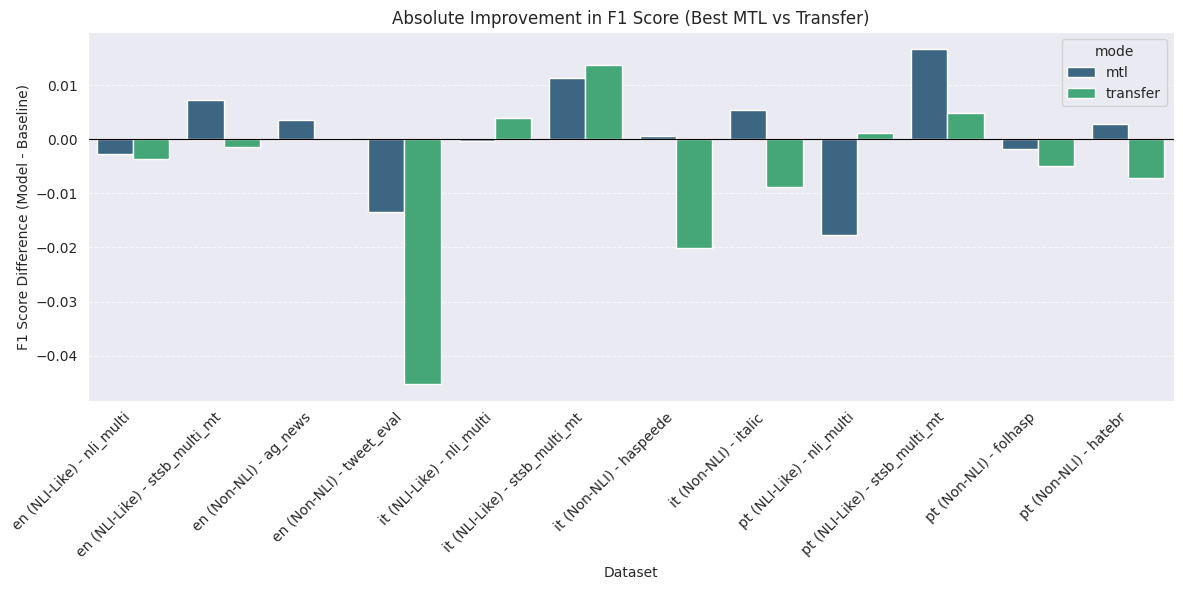

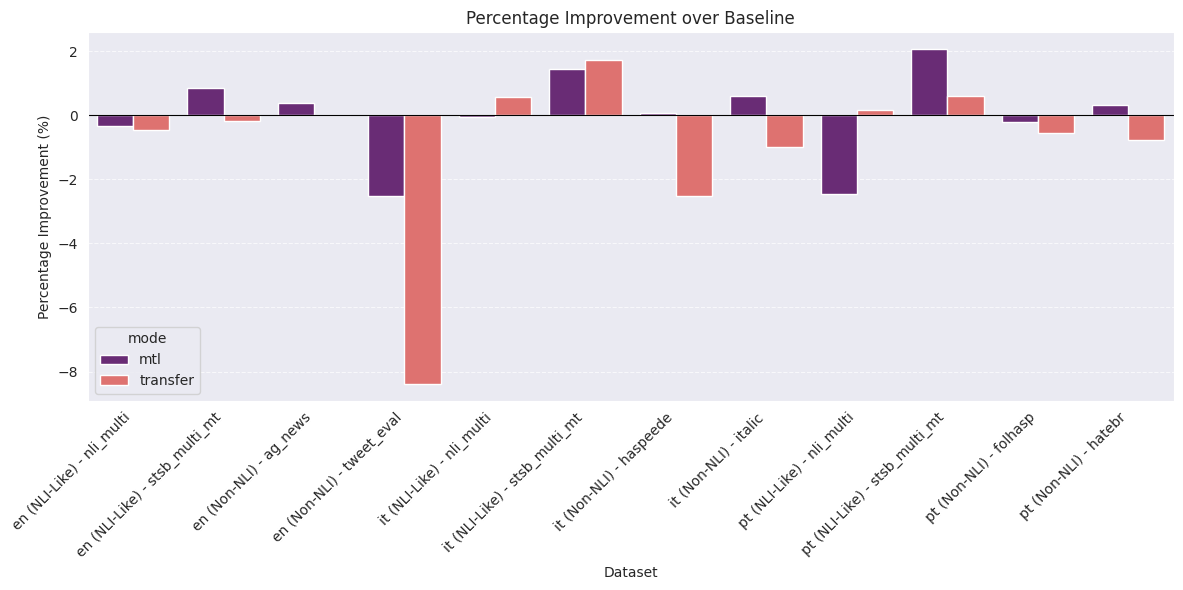

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('results-page1.tsv', sep='\t')

cols_to_fix = ['acc', 'f1']
for col in cols_to_fix:
    if df[col].dtype == 'O':
        df[col] = df[col].str.replace(',', '.').astype(float)

df = df.dropna(subset=['f1', 'acc'])

baselines = df[df['mode'] == 'baseline'][['language', 'dataset', 'acc', 'f1']]
baselines = baselines.rename(columns={'acc': 'base_acc', 'f1': 'base_f1'})

df_merged = df.merge(baselines, on=['language', 'dataset'], how='left')

df_merged['diff_f1'] = df_merged['f1'] - df_merged['base_f1']
df_merged['pct_diff_f1'] = (df_merged['diff_f1'] / df_merged['base_f1']) * 100

df_best = df_merged[df_merged['mode'] != 'baseline'].loc[
    df_merged[df_merged['mode'] != 'baseline'].groupby(['language', 'dataset', 'mode'])['f1'].idxmax()
]

df_best['label'] = df_best['language'] + " (" + df_best['type']  + ") - " + df_best['dataset']
df_best.sort_values(by='label', inplace=True)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_best, x='label', y='diff_f1', hue='mode', palette='viridis')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.title('Absolute Improvement in F1 Score (Best MTL vs Transfer)')
plt.ylabel('F1 Score Difference (Model - Baseline)')
plt.xlabel('Dataset')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_best, x='label', y='pct_diff_f1', hue='mode', palette='magma')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.title('Percentage Improvement over Baseline')
plt.ylabel('Percentage Improvement (%)')
plt.xlabel('Dataset')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()